In [4]:
from __future__ import print_function, division
import sys,os
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
%matplotlib inline 

font = {
        'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', **font) 

figures_path = "../figs"
model = "EHM_Itensor" 
exec = "Phase_Diagram"
results = "../results"

U_max = 8.0
V_max = 6.0

N_Points = 50
L = 13

In [5]:
def load_data(L, U_max, V_max, N_Points):

    # Generate discretized U and V values
    U_vals = np.loadtxt(f"{results}/{model}_{exec}/U_vals_NPoints={N_Points}.txt")
    V_vals = np.loadtxt(f"{results}/{model}_{exec}/V_vals_NPoints={N_Points}.txt")

    U_vals = np.array(U_vals)
    V_vals = np.array(V_vals)

    magnetization = np.zeros((N_Points, N_Points, L))
    charge_density = np.zeros((N_Points, N_Points, L))

    # Loop over U and V values
    for i, U_f in enumerate(U_vals):
        for j, V_f in enumerate(V_vals):
            info_output = f"{results}/{model}_{exec}/XXXXX_{model}_L={L}_U={U_f}_V={V_f}_NPoints={N_Points}.txt"

            str_magnetization = info_output.replace('XXXXX', 'magnetization')
            str_charge_density = info_output.replace('XXXXX', 'charge_density')

            magnetization[i, j] = np.loadtxt(str_magnetization)
            charge_density[i, j] = np.loadtxt(str_charge_density)

    return magnetization, charge_density, U_vals, V_vals

In [6]:
def m_SDW(L, Sj): 
    m_sdw = 0
    for j in range(L):
        m_sdw += (-1)**(j) * (Sj[j])
    return m_sdw / L

def m_CDW(L, nj): 
    m_cdw = 0
    for j in range(L):
        m_cdw += (-1)**(j) * (nj[j] - 1)
    return m_cdw / L 

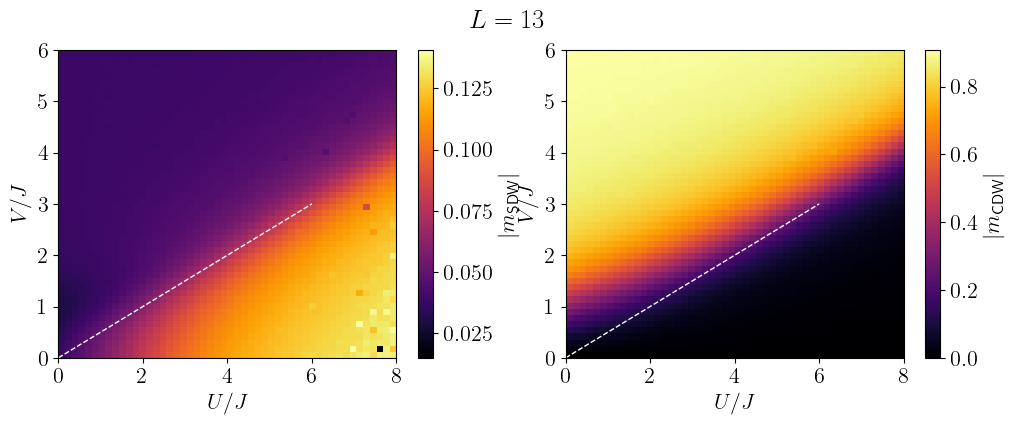

In [7]:
magnetization, charge_density, U_vals, V_vals = load_data(L, U_max, V_max, N_Points)

m_sdw = np.zeros((N_Points, N_Points))
m_cdw = np.zeros((N_Points, N_Points))

for i, U in enumerate(U_vals):
    for j, V in enumerate(V_vals):

        magnetization_ij = magnetization[i, j]
        charge_density_ij = charge_density[i, j]

        m_sdw[i, j] = np.abs(m_SDW(L, magnetization_ij))
        m_cdw[i, j] = np.abs(m_CDW(L, charge_density_ij))

# The data in m_sdw and m_cdw are transposed!
m_sdw = m_sdw.T 
m_cdw = m_cdw.T

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
plt.suptitle(f"$L = {L}$")

# Plot m_SDW heatmap
im0 = ax[0].imshow(m_sdw, origin="lower", extent=[0, U_max, 0, V_max], aspect="auto", cmap="inferno")
fig.colorbar(im0, ax=ax[0], label=r"$|m_{\text{SDW}}|$")
ax[0].set_xlabel(r"$U / J$")
ax[0].set_ylabel(r"$V / J$")
#ax[0].set_title(r"$m_{\text{SDW}}=(1/L) \sum_{j}(-1)^j \langle \hat{S}_{j}^{z} \rangle$")

# Plot m_CDW heatmap
im1 = ax[1].imshow(m_cdw, origin="lower", extent=[0, U_max, 0, V_max], aspect="auto", cmap="inferno")
fig.colorbar(im1, ax=ax[1] , label=r"$|m_{\text{CDW}}|$")
ax[1].set_xlabel(r"$U / J$")
ax[1].set_ylabel(r"$V / J$")
#ax[1].set_title(r"$m_{\text{CDW}}=(1/L)\sum_{j}(-1)^j (\langle \hat{n}_j \rangle-1)$")

# Plot line U = 2V
V_range = np.linspace(0, V_max / 2, N_Points)
U_range = 2 * V_range 
ax[0].plot(U_range, V_range, 'w--', linewidth=1)  
ax[1].plot(U_range, V_range, 'w--', linewidth=1)  

# Save the figure
plt.savefig(f"{figures_path}/{model}_{exec}/order_parameters_L={L}_Npoints={N_Points}_Umax={U_max}_Vmax={V_max}.png", dpi=300, bbox_inches="tight")
plt.show()

- Energy


In [8]:
def load_energy(L, U_max, V_max, N_Points):

    # Generate discretized U and V values
    U_vals = np.loadtxt(f"{results}/{model}_{exec}/U_vals_NPoints={N_Points}.txt")
    V_vals = np.loadtxt(f"{results}/{model}_{exec}/V_vals_NPoints={N_Points}.txt")

    U_vals = np.array(U_vals)
    V_vals = np.array(V_vals)

    energy = np.zeros((N_Points, N_Points))

    # Loop over U and V values
    for i, U_f in enumerate(U_vals):
        for j, V_f in enumerate(V_vals):
            info_output = f"{results}/{model}_{exec}/XXXXX_{model}_L={L}_U={U_f}_V={V_f}_NPoints={N_Points}.txt"

            str_energy = info_output.replace('XXXXX', 'E_GS')
            energy[i, j] = np.loadtxt(str_energy)
    return energy, U_vals, V_vals

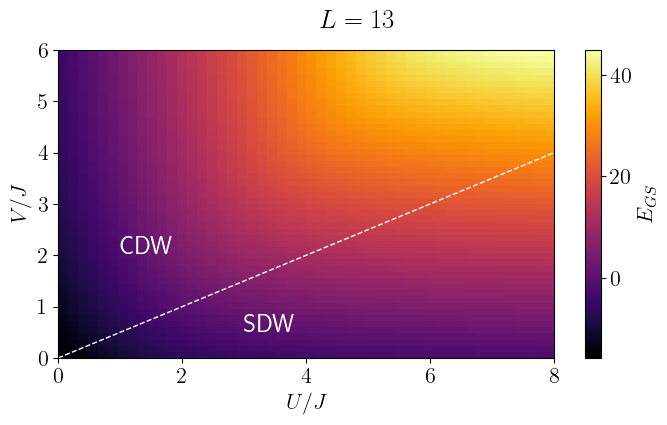

In [10]:
Ls = [13]
for L in Ls:
    energy, U_vals, V_vals = load_energy(L, U_max, V_max, N_Points)
    # Create a figure with two subplots
    fig, ax = plt.subplots(1, 1, figsize=(8, 4), sharex=True)
    im0 = ax.imshow(energy, origin="lower", extent=[0, U_max, 0, V_max], aspect="auto", cmap="inferno")
    fig.colorbar(im0, ax=ax, label=r"$E_{GS}$")
    ax.set_xlabel(r"$U / J$")
    ax.set_ylabel(r"$V / J$")

    # Plot line U = 2V
    V_range = np.linspace(0, U_max / 2, N_Points)
    U_range = 2 * V_range 
    ax.plot(U_range, V_range, 'w--', linewidth=1)  
    
    ax.text(1, 2, "$\\text{CDW}$", color = "white", fontsize=18)
    ax.text(3, 0.5, "$\\text{SDW}$", color = "white", fontsize=18)
    
    plt.suptitle(f"$L = {L}$")
    plt.show()
    fig.savefig(f"{figures_path}/{model}_{exec}/E_GS={L}_{model}_NPoints={N_Points}.png", dpi = 500, bbox_inches='tight')
